In [1]:
clean_up = True # if True, remove all gams related files from working folder before starting
%run stdPackages.ipynb

*Load specific modules used here:*

In [2]:
os.chdir(main)
%run stdPlotting.ipynb

# Plot recycling function

*Illustrate recycling function and how it relates to key parameters.*

* $a = F(r)$ with $a \equiv A/R$ and $r \equiv R/W$.
* $\partial A/\partial R = F(r)+rF'(r) \equiv G(r)$.

In [3]:
def techF(r, αl = 0, αu = 1, β = 2):
    return αl+(αu-αl)*(1-r.pow(β)/(1+β))
def techG(r, αl = 0, αu = 1, β = 2):
    return αl+(αu-αl)*(1-r.pow(β))
def techGInv(y, αl = 0, αu =1 , β=2):
    return ((αu-y)/(αu-αl)).pow(1/β)
def fdAdW(r, αl = 0, αu = 1, β = 2):
    return (αu-αl)*(β/(1+β)) * r.pow(β+1)
def fζe(pm, γr, γe, pe = 1, pz = 1):
    return (pz * (γr-γe)+pe )/pm
def fζeInt(pm, γr, γe, αl = 0, αu = 1, pe = 1, pz = 1, eps = 0.001):
    ζe = fζe(pm,γr,γe, pe = pe, pz = pz)
    return (αl+np.sqrt(np.square(ζe-αl)+np.square(eps))+αu-np.sqrt(np.square(ζe-αu)+np.square(eps)))/2

*Everything is plotted within [0,1] bounds. Add plotting bounds for all plots:*

In [11]:
ylims = [0-.05, 1+0.05]

#### 1. Plot $F, G$: with high/low $\beta$:

*Indices:*

In [7]:
rGrid = pd.Series(np.linspace(0,1,1001))
rGrid.index = pd.Index(rGrid.values, name = '$r$')
βGrid = pd.Series([0.5, 2], index = '$β = $'+pd.Index(['$0.5$               ', '$2$'               ], name = 'β'))
fIdx  = pd.MultiIndex.from_product([rGrid.index, βGrid.index])

In [8]:
ri, βi = adjMultiIndex.bc(rGrid, fIdx), adjMultiIndex.bc(βGrid, fIdx)
dfi = pd.DataFrame({'$A/R$': techF(ri, β = βi), '$\partial A/\partial R$': techG(ri, β=βi)})

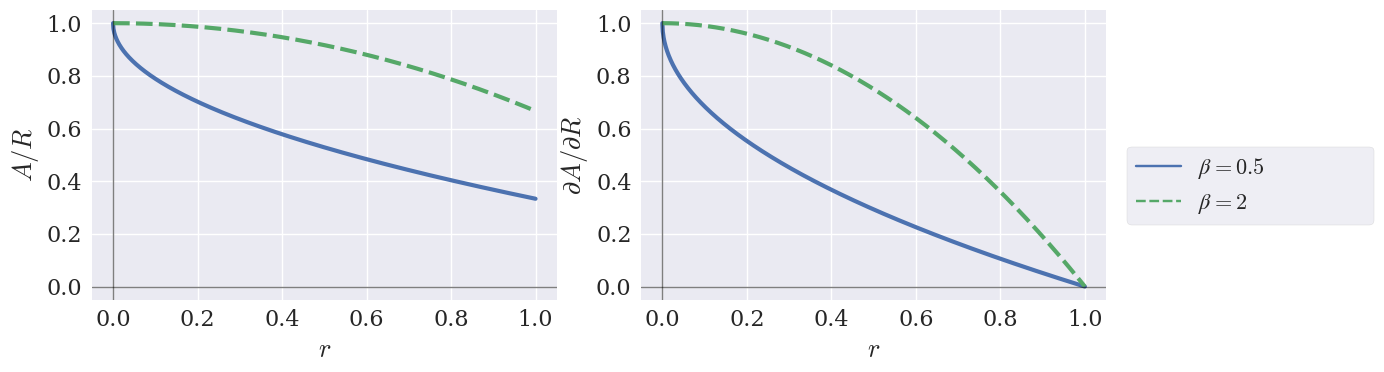

In [15]:
%%capture --no-display
mult_graphs()
nplots, nrows = 2,1
fig,axes = plt.subplots(nrows,min(nplots,2), figsize=(14,(4*nrows)));
for i in range(nplots):
    j = dfi.columns[i]
    ax = plt.subplot(nrows, min(nplots,2), i+1);
    if i == 0:
        seaborn.lineplot(data = dfi[j].unstack('β'), ax = ax, linewidth =3 ,legend='full')
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
    else:
        seaborn.lineplot(data = dfi[j].unstack('β'), ax = ax, linewidth =3 ,legend=False) 
    ax.set_ylabel(j);
    ax.set_ylim(ylims)
    ax.axhline(0, color = 'k', linewidth = 1, alpha = .5);
    ax.axvline(0, color = 'k', linewidth = 1, alpha = .5);
fig.legend(handles, labels, loc = 7, ncol = 1, fontsize = 16, frameon = True)
fig.tight_layout()
fig.subplots_adjust(right=0.8)
fig.savefig(os.path.join(d['figs'],"TechFuncOfBeta.pdf"),edgecolor='k')

#### 2. Plot with $\alpha$ bounds  [0,1] and [0.25, 0.75]:

Set up data:

In [16]:
αl, αu = pd.Series([0, 0.25], index = pd.Index([0, 1], name = 'idx')), pd.Series([1, 0.75], index = pd.Index([0,1], name = 'idx'))
fIdx = pd.MultiIndex.from_product([rGrid.index, αl.index])
ri, αli, αui = adjMultiIndex.bc(rGrid, fIdx), adjMultiIndex.bc(αl, fIdx), adjMultiIndex.bc(αu, fIdx)

Set up dataframe:

In [17]:
dfi = dfi = pd.DataFrame({'$A/R$': techF(ri, αl = αli, αu = αui), '$\partial A/\partial R$': techG(ri, αl=αli, αu = αui)})

Plot:

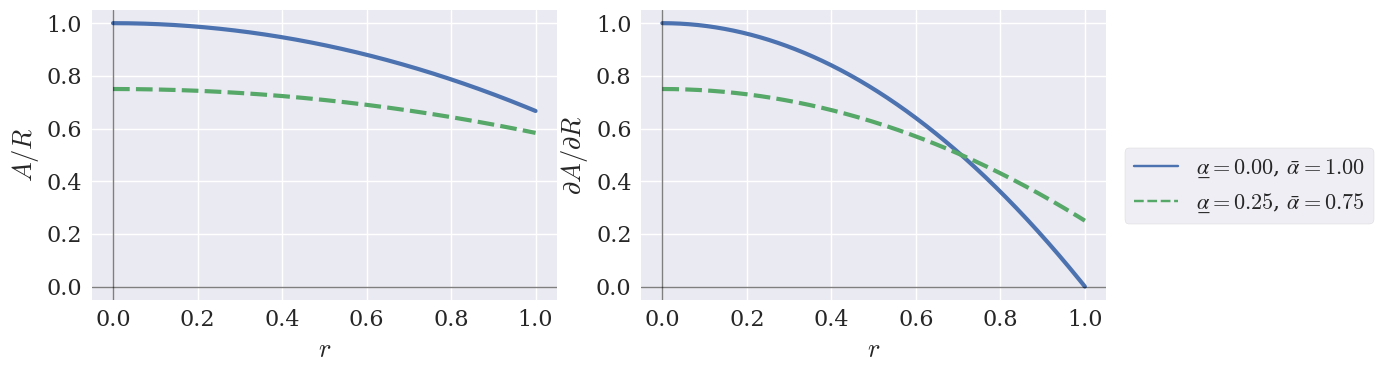

In [23]:
%%capture --no-display
mult_graphs()
nplots, nrows = 2,1
fig,axes = plt.subplots(nrows,min(nplots,2), figsize=(14,(4*nrows)));
for i in range(nplots):
    j = dfi.columns[i]
    ax = plt.subplot(nrows, min(nplots,2), i+1);
    if i == 0:
        data = dfi[j].unstack('idx').rename(columns = {0:'$α\u0332 = 0.00$, $ᾱ = 1.00$', 1: '$α\u0332 = 0.25$, $ᾱ = 0.75$'})
        seaborn.lineplot(data = data, ax = ax, linewidth =3 ,legend='full')
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
    else:
        seaborn.lineplot(data = dfi[j].unstack('idx'), ax = ax, linewidth =3 ,legend=False)
    ax.set_ylabel(j);
    ax.set_ylim(ylims)
    ax.axhline(0, color = 'k', linewidth = 1, alpha = .5);
    ax.axvline(0, color = 'k', linewidth = 1, alpha = .5);
fig.legend(handles, labels, loc = 7, ncol = 1, fontsize = 16, frameon = True)
fig.tight_layout()
fig.subplots_adjust(right=0.8)
fig.savefig(os.path.join(d['figs'],"TechFuncOfAlpha.pdf"),edgecolor='k')

### 3. Derivatives:

Plot derivatives ($\partial A/\partial R$, $\partial A/\partial W$) and average quality as function of $r$: 

In [24]:
dfi = pd.DataFrame({'$A/R$': techF(rGrid), '$\partial A/\partial R$': techG(rGrid), '$\partial A/\partial W$': fdAdW(rGrid)})

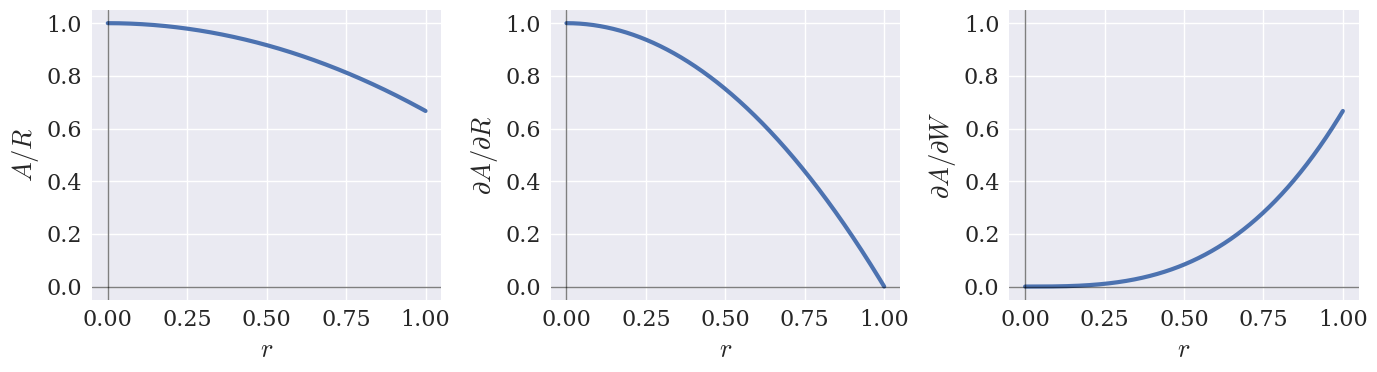

In [25]:
%%capture --no-display
mult_graphs()
fig, axes = plt.subplots(1, 3, figsize = (14,4));
for i in range(len(dfi.columns)):
    j = dfi.columns[i]
    ax = plt.subplot(1, 3, i+1);
    seaborn.lineplot(data = dfi[j], ax = ax, linewidth = 3)
    ax.set_ylim(ylims)
    ax.axhline(0, color = 'k', linewidth = 1, alpha = .5);
    ax.axvline(0, color = 'k', linewidth = 1, alpha = .5);
fig.tight_layout();
fig.savefig(os.path.join(d['figs'],"TechFunc.pdf"),edgecolor='k')

Plot optimal recycling rate as function of the price of recycled materials:

In [26]:
γr, γe = 2, 1
pmGrid = pd.Series(np.linspace(0, 10, 1001))
pmGrid.index = pd.Index(pmGrid.values, name = '$p_m$')

Grid of $\beta$ on top of this:

In [27]:
βGrid = pd.Series([0.5, 2], index = pd.Index([0.5, 2], name = '$β$'))
fIdx  = pd.MultiIndex.from_product([pmGrid.index, βGrid.index])

Solve for optimum:

In [28]:
pmi, βi = adjMultiIndex.bc(pmGrid, fIdx), adjMultiIndex.bc(βGrid, fIdx)
rOpt = techGInv(fζeInt(pmi,γr, γe), β = βi).fillna(0)
aOpt = techF(rOpt, β = βi)
AOpt = rOpt * aOpt
dfi = pd.DataFrame({'$r$': rOpt, '$a$': aOpt, '$A/W$': AOpt})

Print $r^*, a^*, A^*/W$:

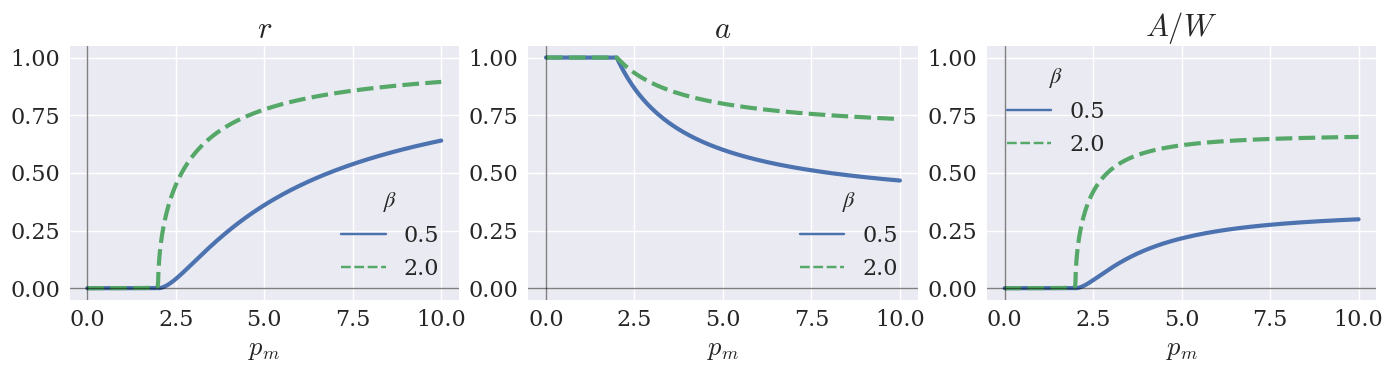

In [29]:
%%capture --no-display
mult_graphs()
fig, axes = plt.subplots(1, 3, figsize = (14,4));
for i in range(len(dfi.columns)):
    j = dfi.columns[i]
    ax = plt.subplot(1, 3, i+1);
    seaborn.lineplot(data = dfi[j].unstack('$β$'), ax = ax, linewidth = 3)
    ax.set_title(j)
    ax.set_ylim(ylims)
    ax.axhline(0, color = 'k', linewidth = 1, alpha = .5);
    ax.axvline(0, color = 'k', linewidth = 1, alpha = .5);
fig.tight_layout();
fig.savefig(os.path.join(d['figs'],"TechFuncOfPm.pdf"),edgecolor='k')